# CNN Assignment
Based on Tensorflow tutorial https://www.tensorflow.org/tutorials/images/cnn?utm_source=chatgpt.com
Using https://www.kaggle.com/datasets/sharansmenon/animals141

# Resize
Resizes all images in the classes to (128*128) sizes

In [18]:
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

tf.random.set_seed(11)
DATA_DIR = "../data/cats"
IMG_SIZE = (128, 128)

ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True,
    seed=42,
)
print(ds.class_names)

Found 257 files belonging to 7 classes.
['acinonyx-jubatus', 'felis-catus', 'panthera-leo', 'panthera-onca', 'panthera-pardus', 'panthera-tigris', 'puma-concolor']


# Show Before / After resize

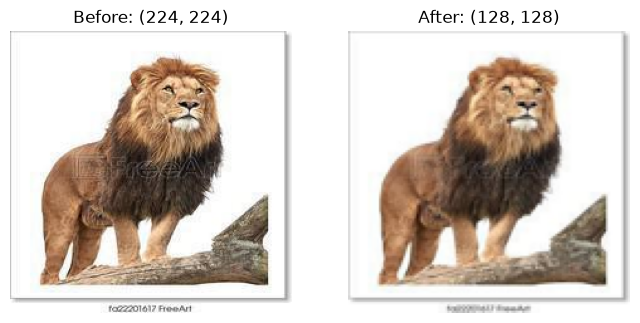

In [ ]:
img_path = next(Path(DATA_DIR, "panthera-leo").glob("*"))   # one lion image
orig = Image.open(img_path)
resized = orig.convert("RGB").resize(IMG_SIZE)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(orig);    ax[0].set_title(f"Before: {orig.size}")
ax[1].imshow(resized); ax[1].set_title(f"After: {resized.size}")
for a in ax: a.axis("off")
plt.savefig("../images/before_after_resize.png", bbox_inches="tight")
plt.show()

# Class Counter
To count how many images we have per class

In [5]:
from pathlib import Path

for c in sorted(Path("../data/cats").iterdir()):
    if c.is_dir():
        print(c.name, len(list(c.glob("*"))))

acinonyx-jubatus 33
felis-catus 33
panthera-leo 47
panthera-onca 49
panthera-pardus 34
panthera-tigris 28
puma-concolor 33


# Splitting
Selected split 70/15/15 from 275 images, so 
1. 180 Train
2. 39 Validation
3. 38 Test

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

all_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=257,
    shuffle=False,
)
class_names = all_ds.class_names
images, labels = next(iter(all_ds))
x = images.numpy() #input
y = labels.numpy() #answers

# Splitting
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.30, stratify=y, random_state=11
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=11
)

# Shape gives (N, W, H, layers), not only like .count
print("Shapes:", x_train.shape, x_val.shape, x_test.shape)
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, np.bincount(arr, minlength=7))

Found 257 files belonging to 7 classes.
Shapes: (179, 128, 128, 3) (39, 128, 128, 3) (39, 128, 128, 3)
train [23 23 33 34 24 19 23]
val [5 5 7 8 5 4 5]
test [5 5 7 7 5 5 5]


# Normalization
Basically turning the numbers to 0 and 1s

In [15]:
# Before: pixel values are 0-255
print("Before:", x_train.min(), x_train.max())

x_train = x_train / 255.0
x_val   = x_val   / 255.0
x_test  = x_test  / 255.0

# After: pixel values are 0-1
print("After: ", x_train.min(), x_train.max())

Before: 0.0 255.0
After:  0.0 1.0


# Data Augmentation
Flipping, rotating input images to increase training samples.

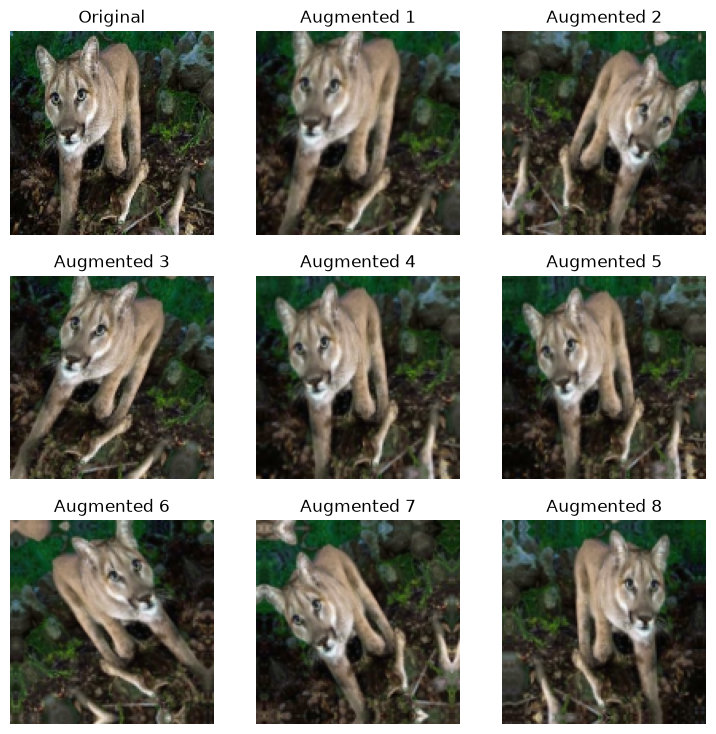

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Preview: original first, then 8 random augmented versions of the same image
img = tf.cast(x_train[0:1], tf.float32)

plt.figure(figsize=(9, 9))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    if i == 0:
        plt.imshow(img[0].numpy())
        plt.title("Original")
    else:
        aug = data_augmentation(img, training=True)
        plt.imshow(aug[0].numpy())
        plt.title(f"Augmented {i}")
    plt.axis("off")
plt.savefig("../images/augmentation_examples.png", bbox_inches="tight")
plt.show()

# Task 3

# Implementing Tensorflow

In [22]:
from tensorflow.keras import layers, models
import json

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,                      # only active during training

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(7),                        # 7 classes, one score each
])

model.summary()

summary = {
    "model_name": model.name,
    "total_params": int(model.count_params()),
    "layers": [],
}

for layer in model.layers:
    try:
        out_shape = str(layer.output.shape)
    except Exception:
        out_shape = "n/a"
    summary["layers"].append({
        "name": layer.name,
        "type": layer.__class__.__name__,
        "output_shape": out_shape,
        "params": int(layer.count_params()),
    })

with open("../results/model_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved ../results/model_summary.json")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,263 (2.05 MB)

 Trainable params: 536,263 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Saved ../results/model_summary.json
